<a href="https://colab.research.google.com/github/gitnicolas343/intro_neurociencias_Computacionesles_phyton/blob/main/Lab9_Red_de_Hopfield_VClase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 8: Memoria asociativa usando Redes de Hopfield

### Redes de Hopfield

La red de Hopfield es una red neuronal artificial que almacena un conjunto de patrones como atractores de su dinámica. El estado de la red está representado por un vector $S_i$ con $i = 1,2,...,N$, donde $N$ es el número de nodos en la red. Consideraremos nodos que solo pueden tomar los valores discretos $\pm 1$.

La dinámica de la red está descrita por la regla de actualización:

$$
S_i(t+\Delta t) = sgn(\sum_j w_{ij}S_j)
$$

Aquí, la matriz $w_{ij}$ representa las conexiones entre los nodos.

Existen dos formas de implementar la actualización de los nodos. Una forma es actualizar todos los nodos al mismo tiempo, lo que se conoce como actualización "sincrónica". La otra forma es actualizar los nodos uno por uno, lo que se denomina actualización "asincrónica". Estas dos formas no son equivalentes, ya que en la actualización sincrónica, el nuevo valor de cada nodo depende de los valores anteriores de todos los nodos, mientras que en la actualización asincrónica, incluso si recorremos todos los nodos en cada ronda de actualizaciones, el nuevo valor de un nodo dependerá de los nuevos valores de los nodos que ya han sido actualizados en la misma ronda (y de los valores antiguos de aquellos que aún no se han actualizado). Usaremos para esta implementación una regla asincrónica.

Un patrón es un estado de la red en el que cada nodo toma un valor específico $p_i^{\mu}$. Para que un patrón determinado se almacene en la red, debe ser un estado estacionario estable de la dinámica. En ese caso, si inicializamos la red en un estado cercano al patrón (un estado "semilla"), la red seguirá su dinámica y convergerá al estado estacionario, recuperando así el patrón almacenado.

Hopfield encontró una forma sencilla de construir $w_{ij}$ que permite a la red almacenar múltiples patrones,
$p_i^{\mu}$ para $\mu = 1,...,M$. La matriz de conectividad debe tener la forma

$$
w_{ij} = \frac{1}{N} \sum_{\mu = 1}^M p_i^{\mu} p_j^{\mu}
$$

Con esta matriz de conexiones, cada patrón es un estado estacionario localmente estable. Por lo tanto, si proporcionamos a la red una semilla cercana a uno de los patrones, la red recuperará automáticamente el patrón completo correcto.

Es posible calcular en cada momento cómo la red va evolucionando hacia alguno de los patrones a través del *overlap* definido como

$$
m^\mu(t) = \frac{1}{N} \sum_i p_i^{\mu} S_i(t)
$$

Si el overlap es igual a 1 quiere decir que la red ha recuperado exitosamente el ítem de memoria.

Implementemos la red de Hopfield siguiendo las siguientes instrucciones.

Primero almacenaremos dos ítems de memoria en una red de Hopfield. Para ello le he preparado la foto de Einstein y la del cocodrilo. Ejecute el siguiente trozo de snippet para cargar las fotos, reducirlas a un tamaño y transformar la imagen reducida en "pixeles" con valores $\pm 1$.

In [100]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


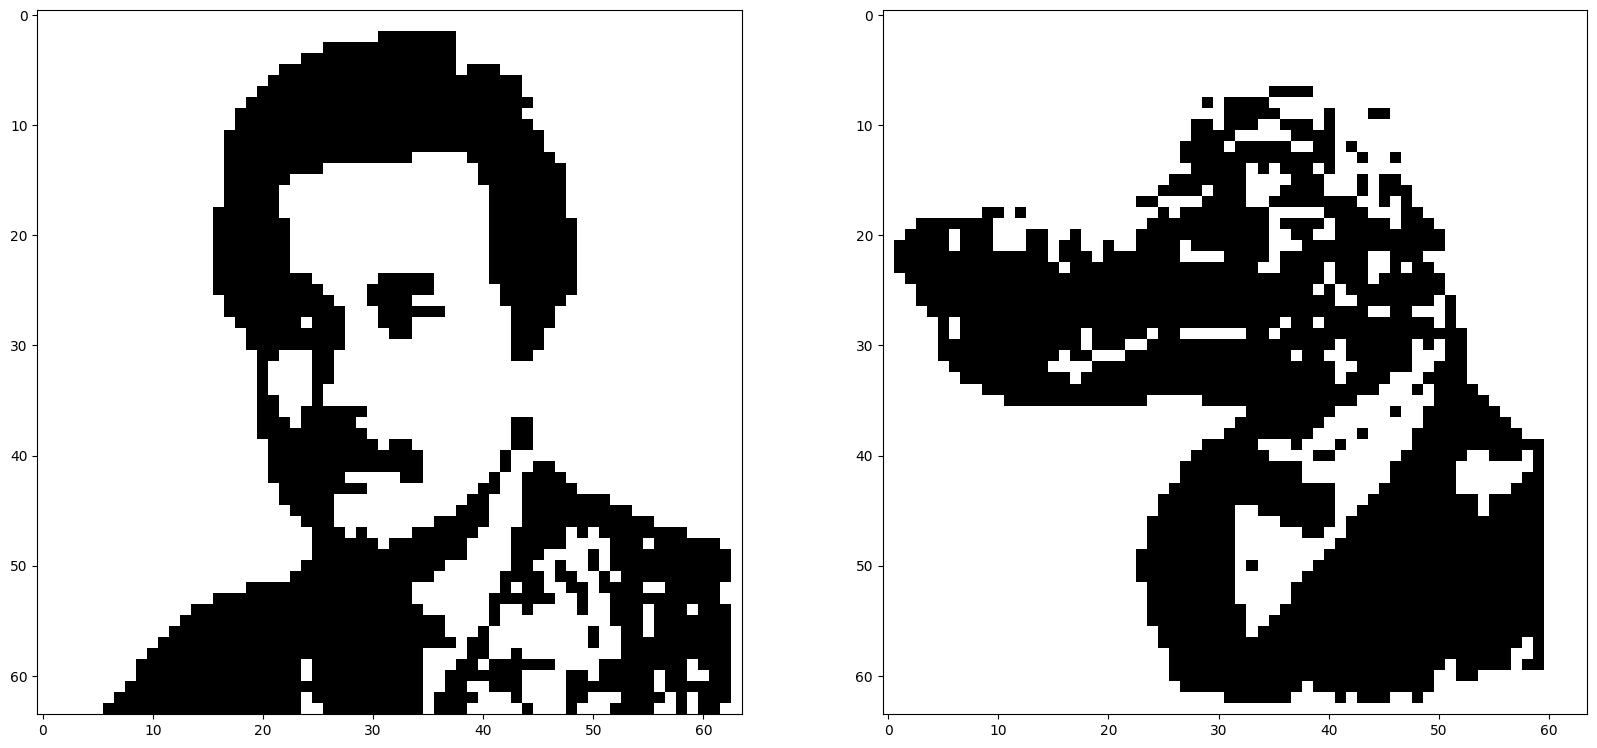

In [101]:
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np


img1 = Image.open('/content/drive/MyDrive/datos/einstein.png')
img2 = Image.open('/content/drive/MyDrive/datos/cocodrilo.png')

new_h = 64
new_i = 64

img1_small = img1.resize((new_h,new_i))
img2_small = img2.resize((new_h,new_i))

p1 = np.asarray(img1_small)[:,:,0]>150
p2 = np.asarray(img2_small)[:,:,0]>150

p1 = 2*p1-1
p2 = 2*p2-1

plt.figure(figsize=(20,15))
plt.subplot(1,2,1)
plt.imshow(p1,cmap='Greys_r')
plt.subplot(1,2,2)
plt.imshow(p2,cmap = 'Greys_r')
plt.show()

1. Transforme las matrices anteriores en arreglos 1 dimensionales para crear los patrones $p^1$ y $p^2$. Recuerde que si bien para nosotros tiene sentido interpretar estos datos como imágenes, en realidad el ítem de memoria es tan solo un arreglo numérico

In [102]:
# TODO
p1_flat = p1.flatten()
p2_flat = p2.flatten()


2. Utilice la ecuación (2) para construir la matriz $w_{ij}$ que almacena los dos patrones

In [103]:
# TODO
N = 64*64
w_ij = np.zeros((N,N))



for  i in range(N):
    for j in range(N):
       w_ij[i,j] += p1_flat[i]*p1_flat[j]
       w_ij[i,j] += p2_flat[i]*p2_flat[j]


w_ij = (1/(N))*w_ij

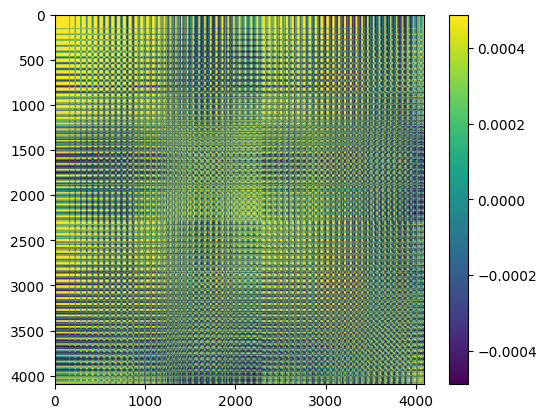

In [104]:
plt.imshow(w_ij, cmap='viridis')
plt.colorbar()
plt.show()

3. Utilice como estado incial de la red una imagen en la que se muestra un recuadro de 20x20 pixeles al interior de una de las dos imágenes

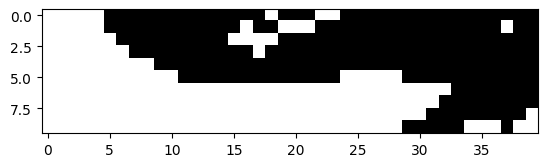

In [105]:
# TODO


w_muestra = p2[30:40,0:40]
plt.imshow(w_muestra,cmap='Greys_r')
plt.show()

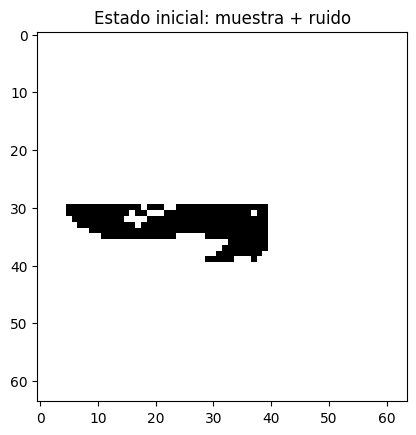

In [106]:
S  = np.ones((64, 64), dtype=int)
S[30:40,0:40] = w_muestra
S_flat = S.flatten()
plt.imshow(S, cmap='Greys_r')
plt.title("Estado inicial: muestra + ruido")
plt.show()

4. Evolucione la red de Hopfield usando la Ecuación (1) usando una actualización asíncrona. En cada iteración almacene el valor de overlap de los dos ítems de memoria.

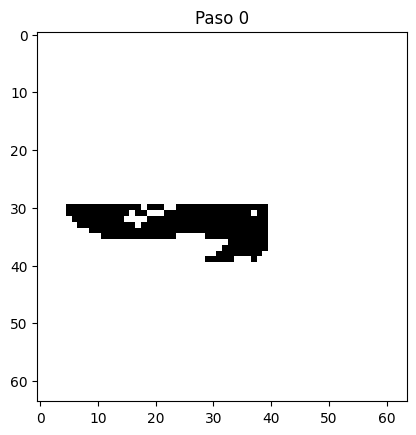

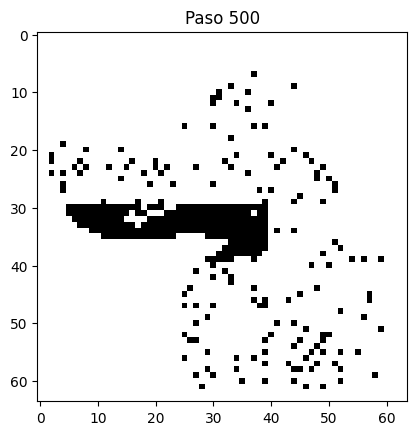

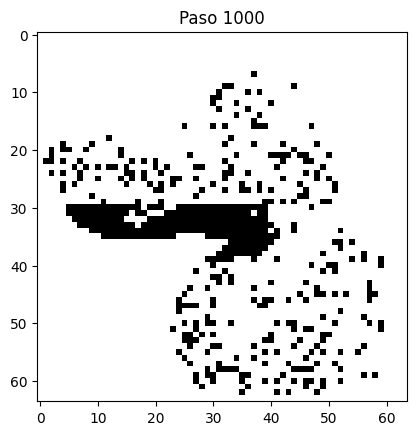

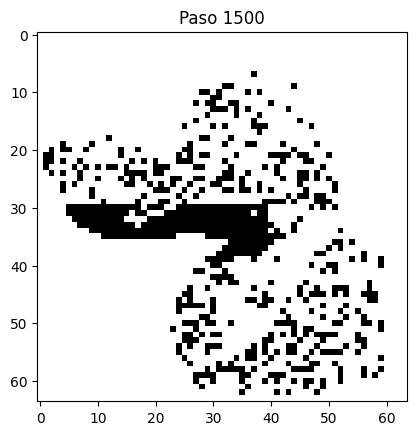

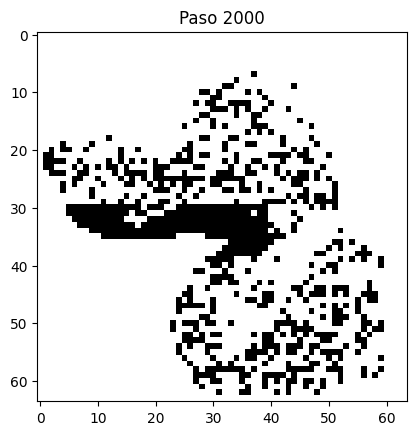

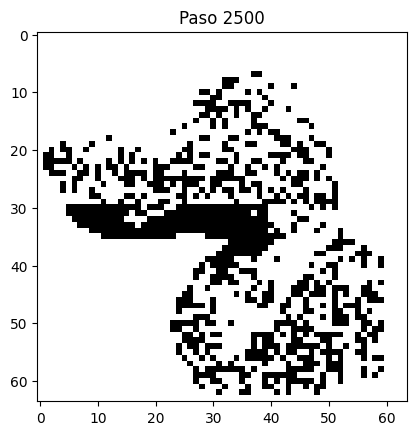

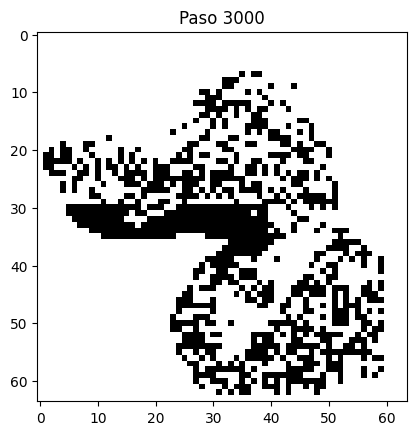

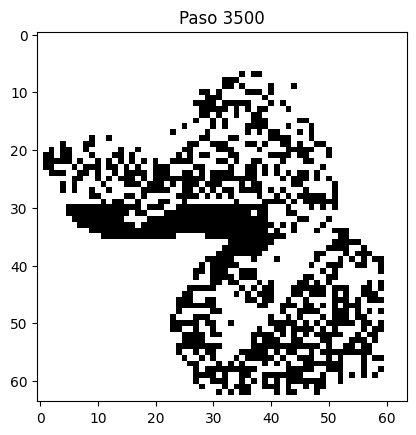

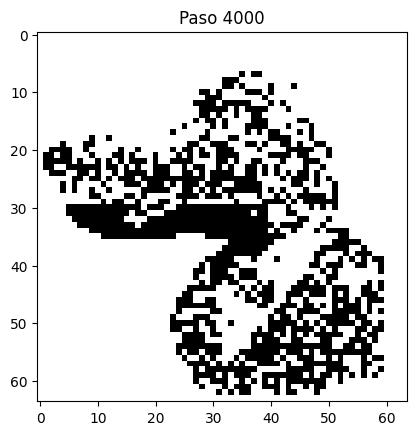

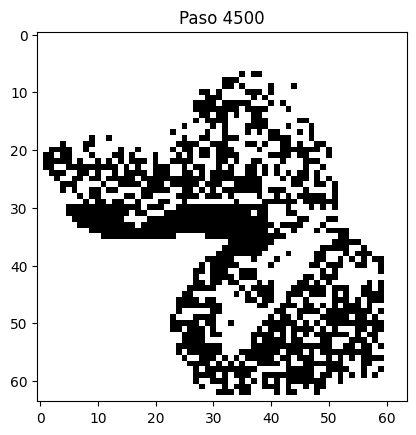

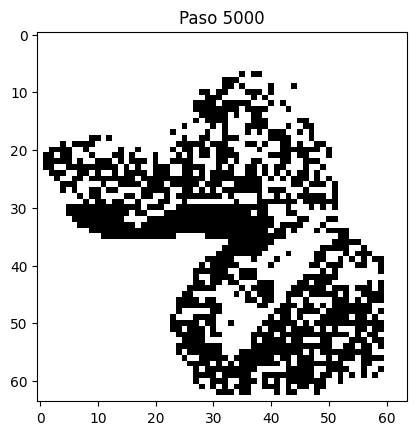

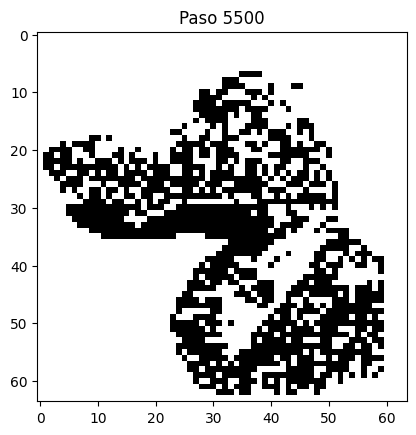

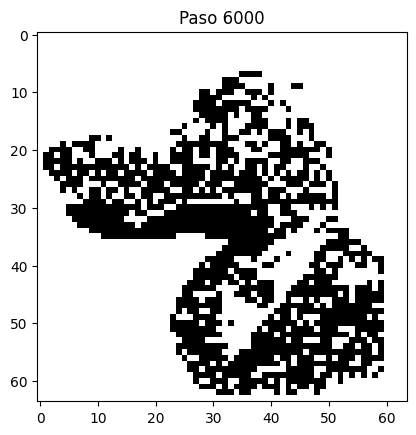

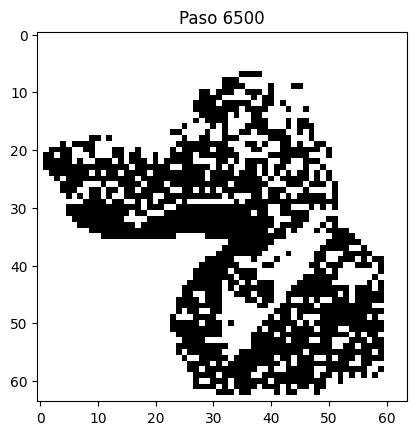

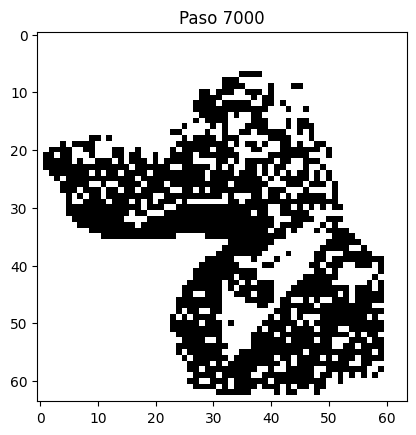

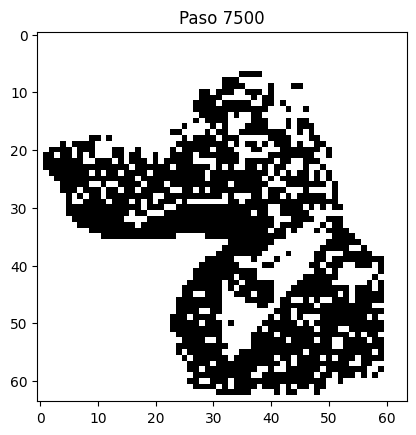

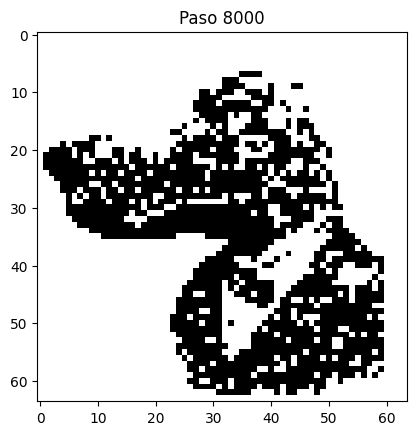

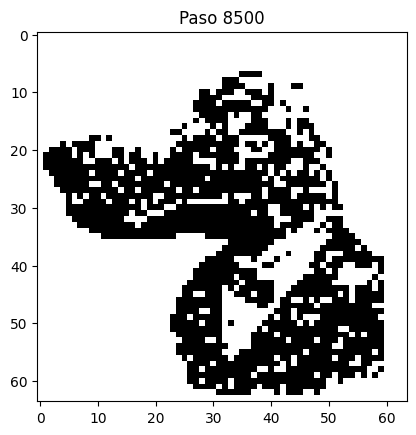

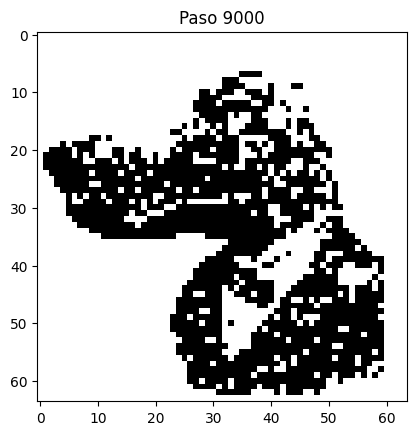

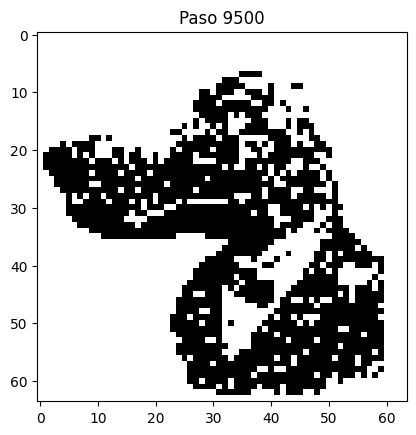

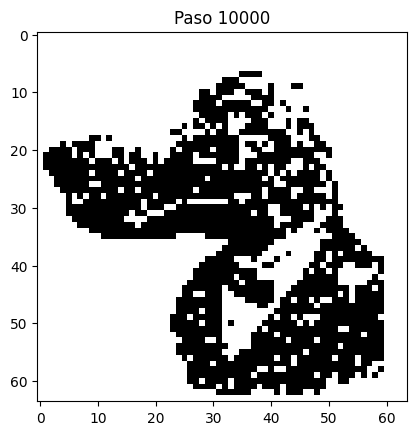

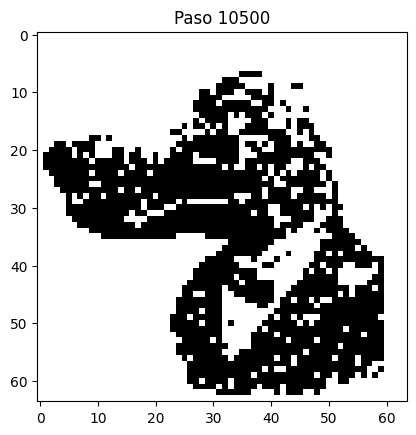

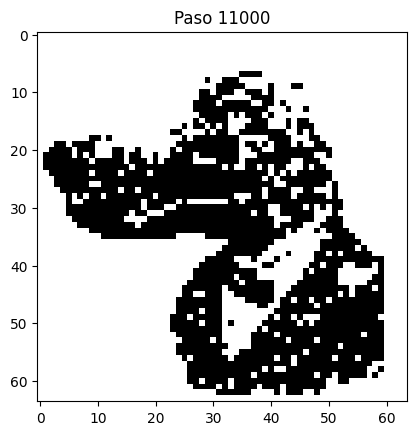

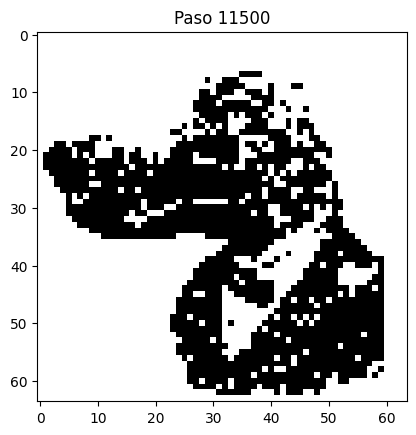

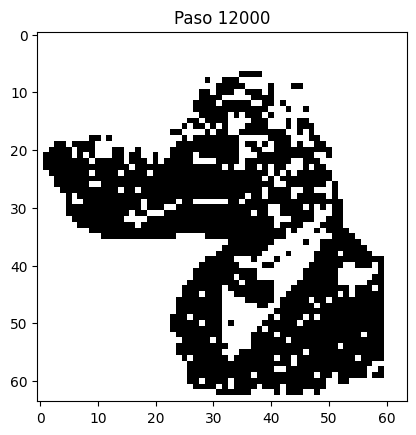

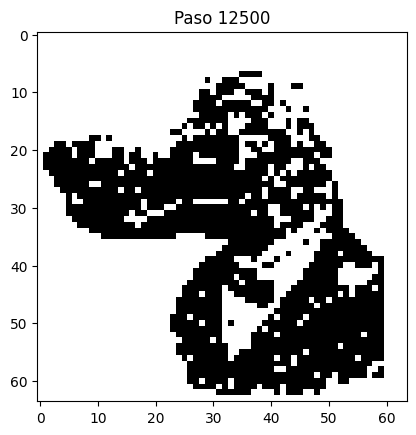

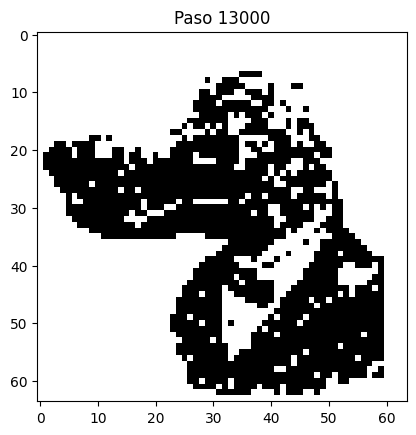

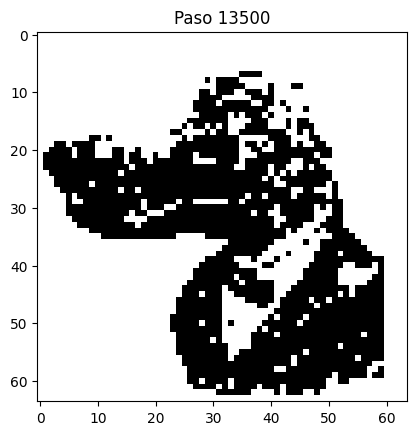

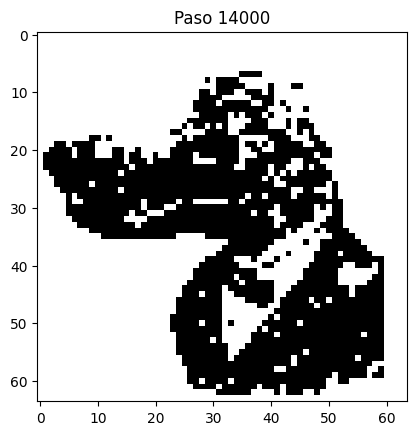

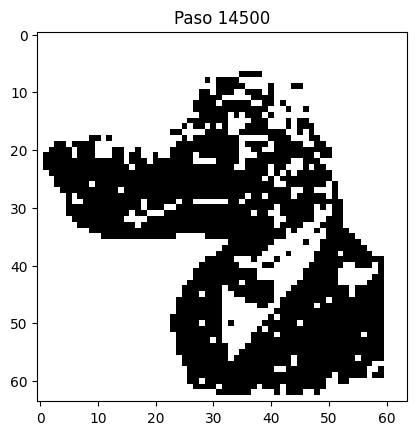

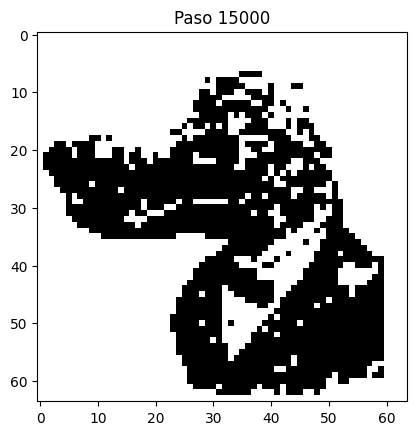

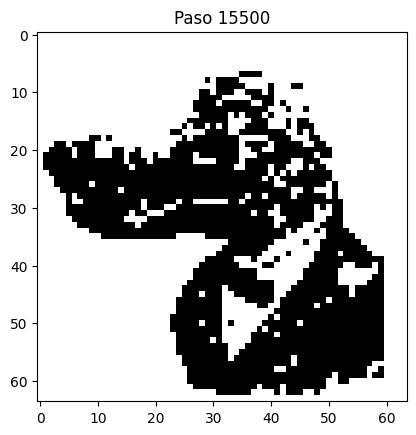

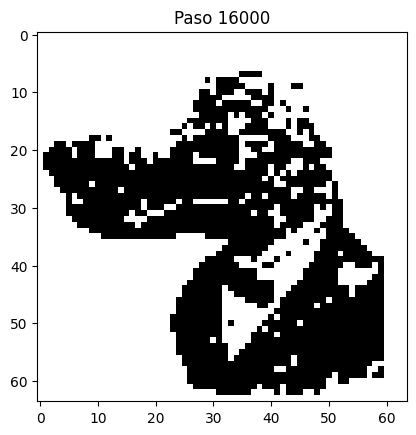

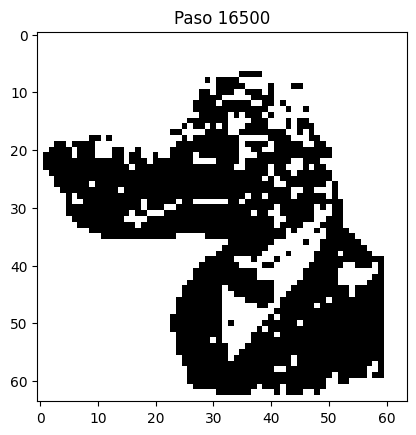

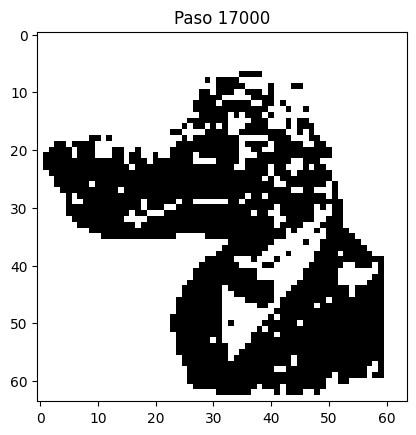

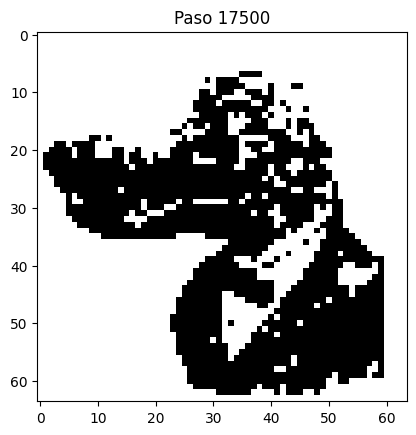

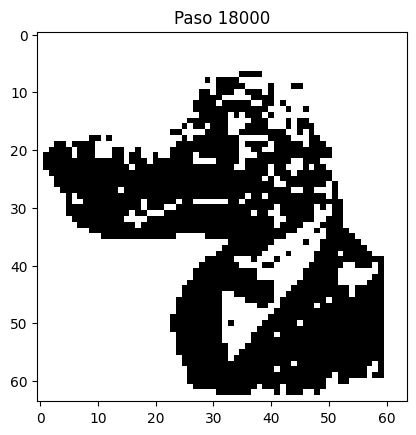

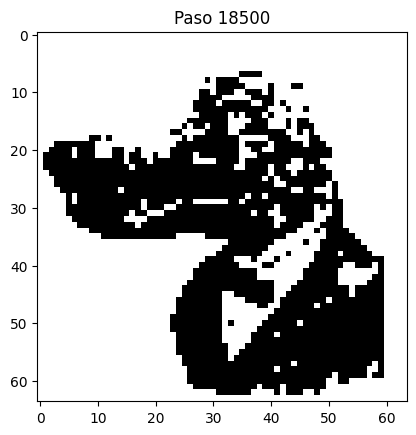

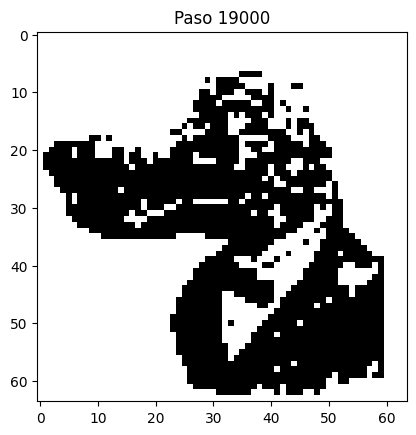

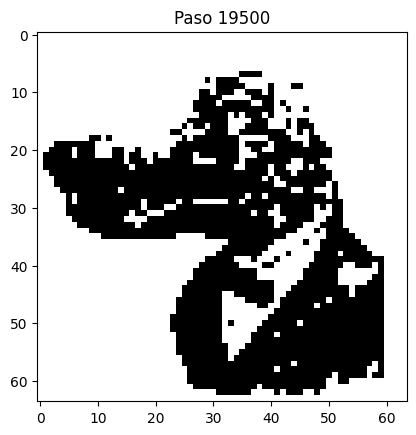

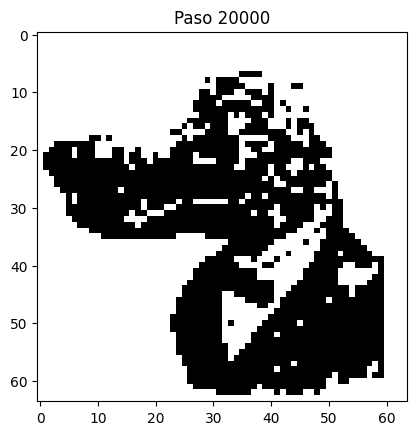

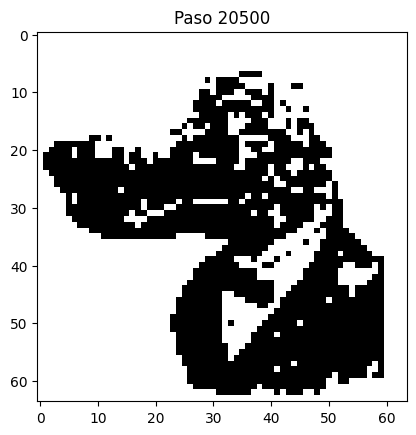

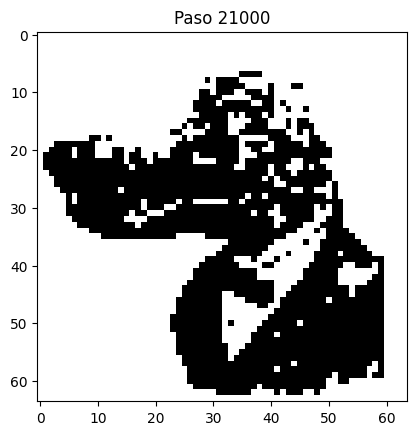

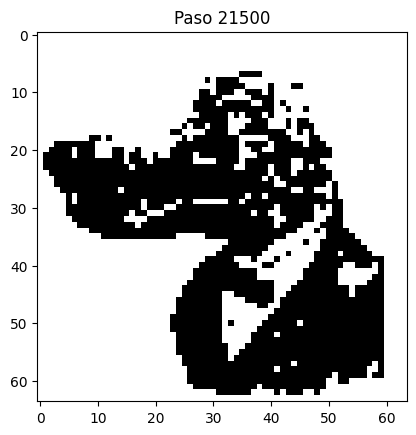

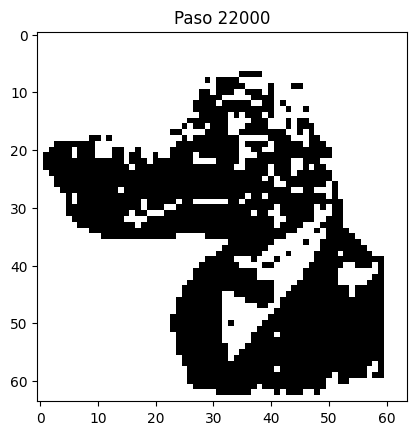

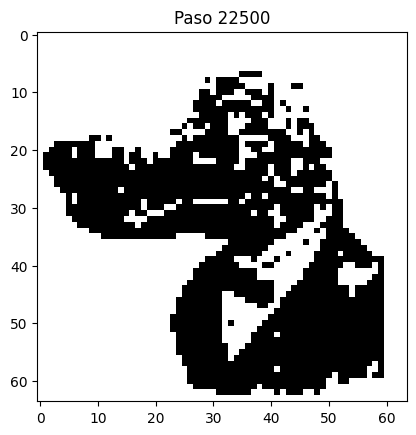

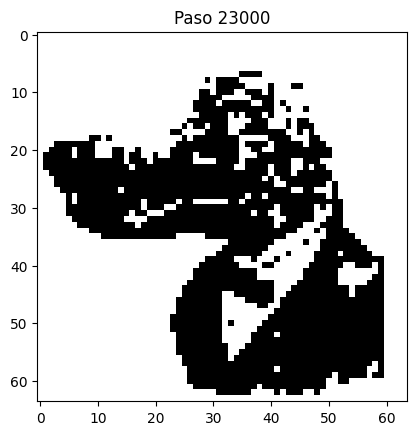

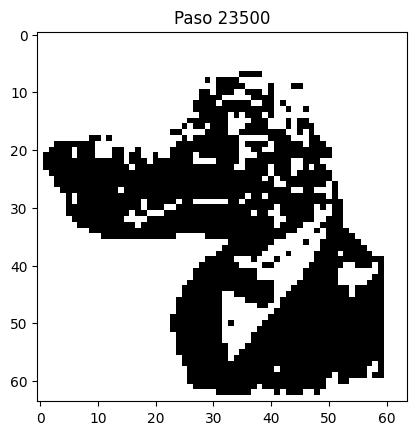

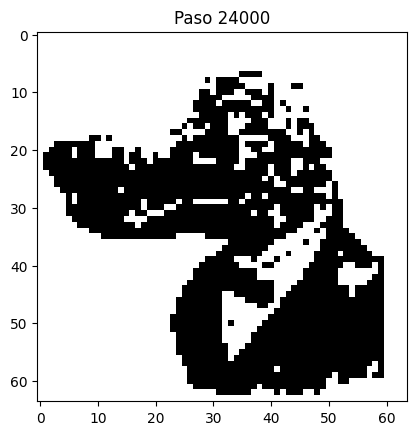

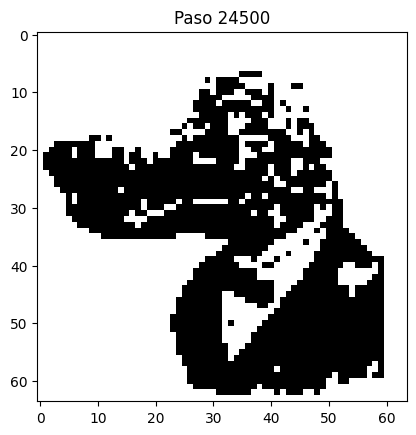

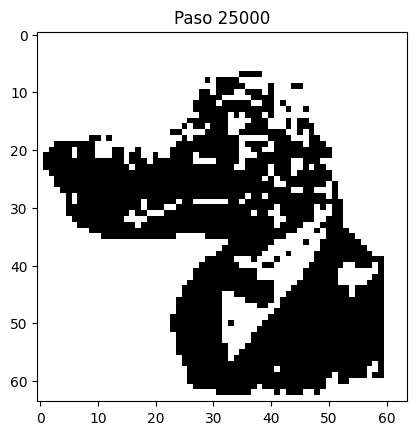

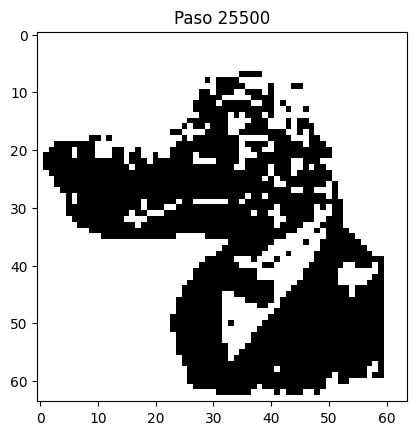

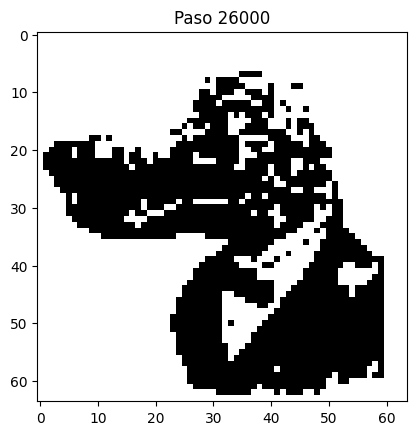

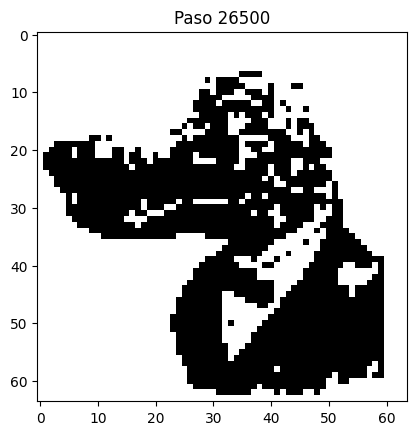

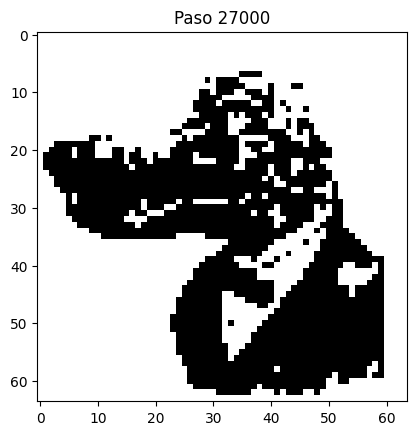

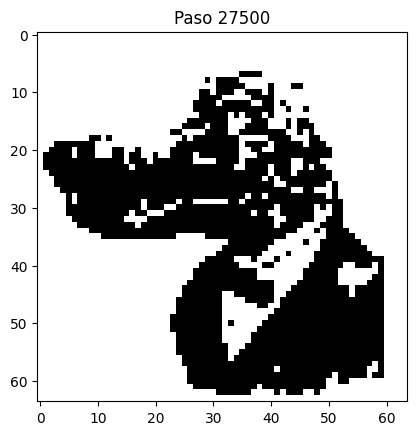

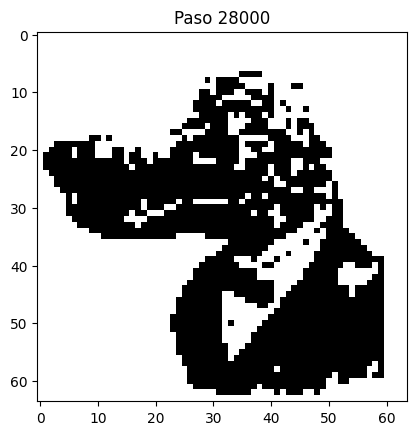

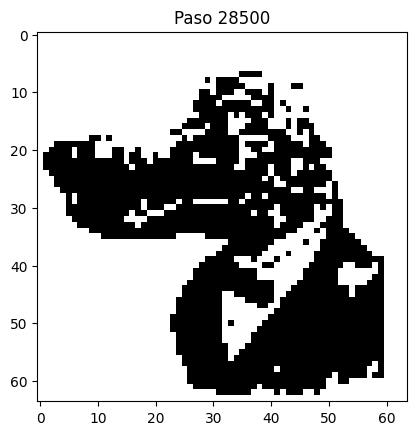

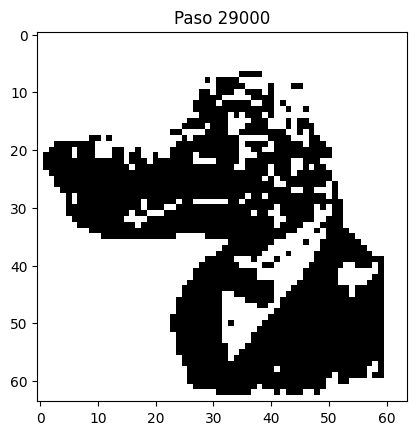

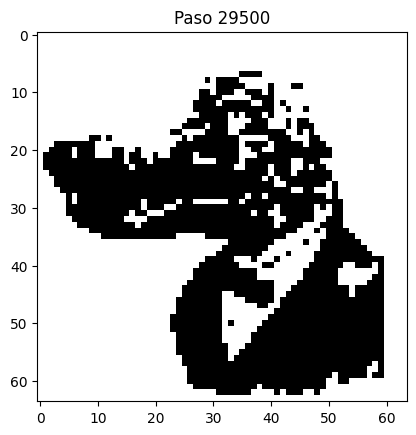

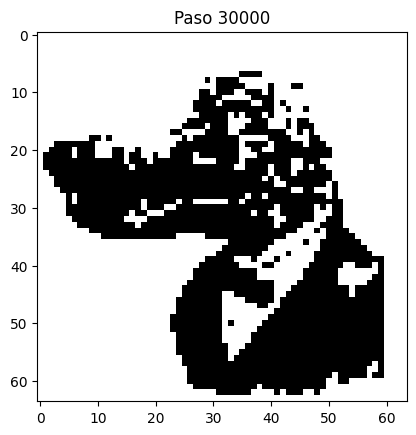

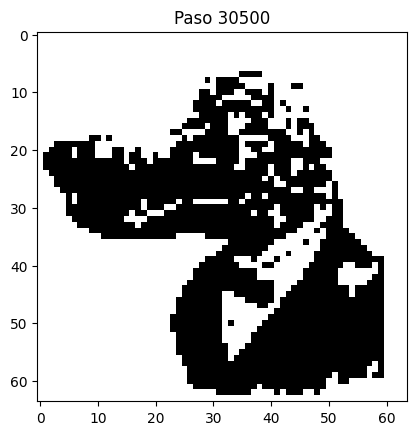

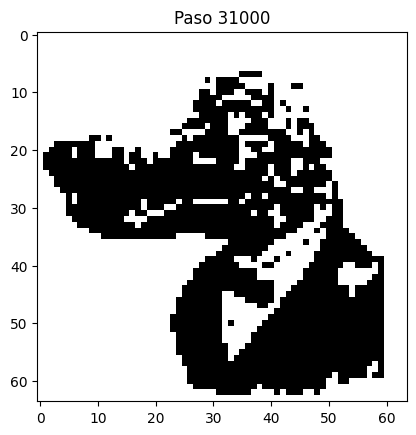

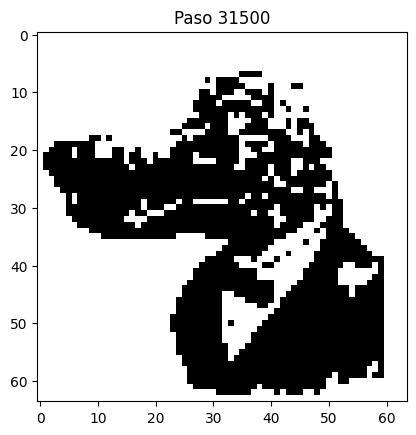

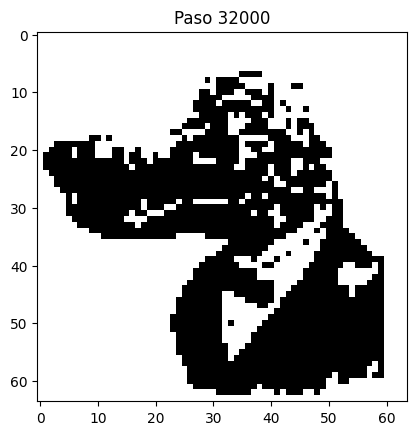

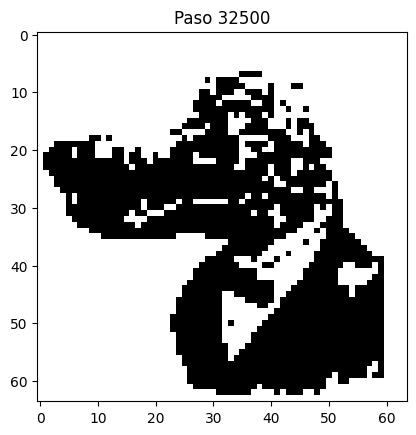

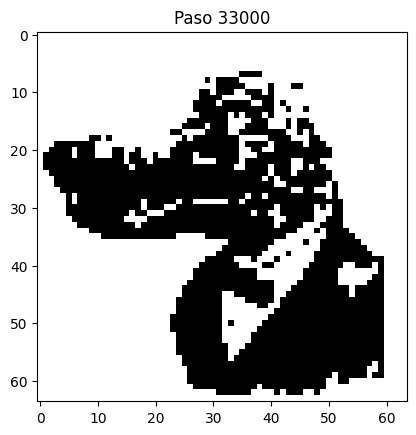

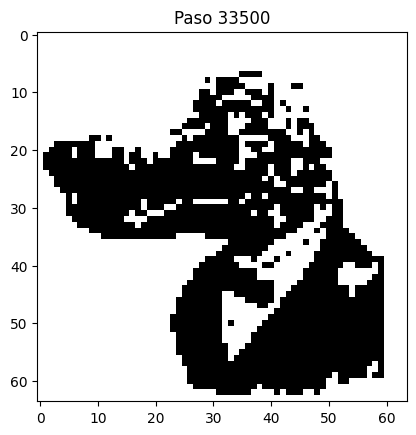

In [123]:
import time

overleap1 = list()
overleap2= list()

S = np.copy(S_flat)  #para no tneer que ejecutar todo el programa


for t in range(34000):
     i = np.random.randint(N)
     h_i = np.dot(w_ij[i],S)  #entrada a la neurona

     #funcion signo
     if h_i >= 0:
        S[i] = 1
     else:
         S[i] = -1

    #calculo del overleap cada cierto tiempo
     if t % 500 == 0:
        m_1 = np.dot(p1_flat,S)/N
        m_2 = np.dot(p2_flat,S)/N
        overleap1.append(m_1)
        overleap2.append(m_2)

     if t % 500 == 0:
        plt.imshow(S.reshape((64, 64)), cmap='Greys_r')
        plt.title(f"Paso {t}")
        plt.axis()
        plt.show()

time.sleep(1)  #esto lo hice por que los ploteos de las imagenes sucesibas crean una suerte de animacion que se puede odservar al ejecutar al entorno


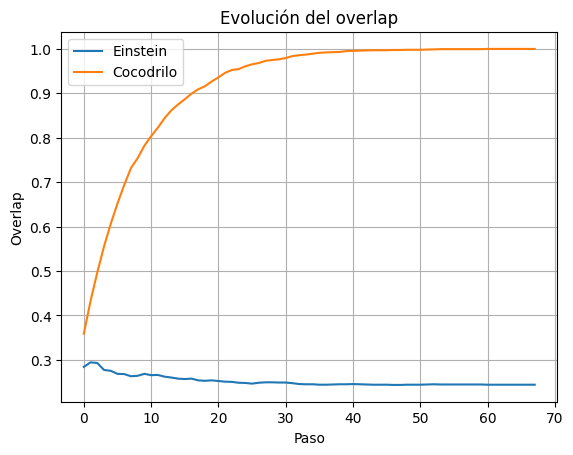

In [121]:
plt.plot(overleap1, label='Einstein')
plt.plot(overleap2, label='Cocodrilo')
plt.xlabel('Paso')
plt.ylabel('Overlap')
plt.legend()
plt.title('Evolución del overlap')
plt.grid()
plt.show()

5. Muestre que efectivamente obtiene la imagen deseada y grafique la evolución del overlap durante el experimento.

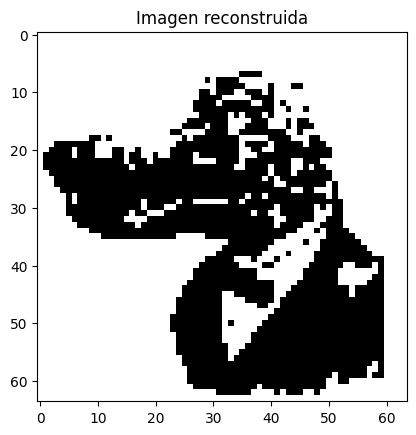

In [122]:

S_final = S.reshape((64, 64))


plt.imshow(S_final, cmap='Greys_r')
plt.title('Imagen reconstruida')
plt.show()
